In [12]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [16]:
df = pd.read_csv("C:\\Users\\sampada\\machine-learning-journey\\Outlier Detection\\placement.csv")

In [18]:
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


In [37]:
df.shape

(1000, 3)

In [ ]:
# step:1 find the distribution of column if  normal then use Z-score

C:\Users\sampada\AppData\Local\Temp\ipykernel_12040\3083813513.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['cgpa'])
C:\Users\sampada\AppData\Local\Temp\ipykernel_12040\3083813513.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['placement_exam_marks'])


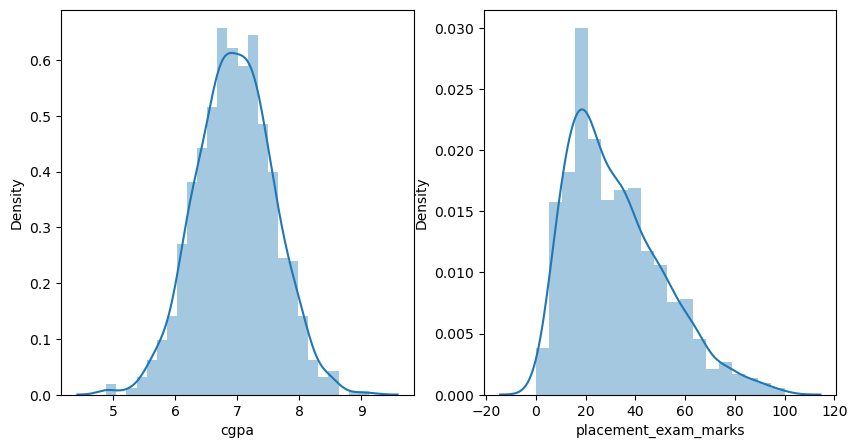

In [24]:
plt.figure(figsize=(10,5))
plt.subplot(121)
sns.distplot(df['cgpa'])


plt.subplot(122)
sns.distplot(df['placement_exam_marks'])

plt.show()

In [26]:
print('mean of cgpa:',df['cgpa'].mean())
print('standard deviation of cgpa:',df['cgpa'].std())
print('maximum number of cgpa:',df['cgpa'].max())
print('minimum number of cgpa:',df['cgpa'].min())

mean of cgpa: 6.96124
standard deviation of cgpa: 0.6158978751323894
maximum number of cgpa: 9.12
minimum number of cgpa: 4.89


In [ ]:
#step2: find the boundary value

In [30]:
print('highest:',df['cgpa'].mean() + 3 * df['cgpa'].std())
print('highes:',df['cgpa'].mean() - 3 * df['cgpa'].std())

highest: 8.808933625397168
highes: 5.113546374602832


In [ ]:
# find the putliers

In [32]:
df[(df['cgpa']>8.80 ) | (df['cgpa']<5.11)]

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


##  outliers removal using Trimming

In [39]:

new_df = df[(df['cgpa']<8.80 ) & (df['cgpa']>5.11)]
new_df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
991,7.04,57.0,0
992,6.26,12.0,0
993,6.73,21.0,1
994,6.48,63.0,0


## By z-score calculation

In [42]:
df['cgpa_score']=(df['cgpa'] - df['cgpa'].mean())/df['cgpa'].std()

In [44]:
df.head()

,cgpa,placement_exam_marks,placed,cgpa_score
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371


In [48]:
df[(df['cgpa_score']>3) | (df['cgpa_score']<-3)]

,cgpa,placement_exam_marks,placed,cgpa_score
485,4.92,44.0,1,-3.314251
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


In [52]:
new_df1 = df[(df['cgpa_score']<3) & (df['cgpa_score']>-3)] # trimming
new_df1

,cgpa,placement_exam_marks,placed,cgpa_score
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371
...,...,...,...,...
991,7.04,57.0,0,0.127878
992,6.26,12.0,0,-1.138565
993,6.73,21.0,1,-0.375452
994,6.48,63.0,0,-0.781363


# Capping

In [57]:
upper_limit = df['cgpa'].mean() + 3 * df['cgpa'].std()
lower_limit = df['cgpa'].mean() - 3 * df['cgpa'].std()

In [59]:
df['cgpa']=np.where(df['cgpa']>upper_limit,upper_limit,np.where(df['cgpa']<lower_limit,lower_limit,df['cgpa']))

In [63]:
df.shape

(1000, 4)

In [65]:
df['cgpa'].describe()

count    1000.000000
mean        6.961499
std         0.612688
min         5.113546
25%         6.550000
50%         6.960000
75%         7.370000
max         8.808934
Name: cgpa, dtype: float64